In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/aqi-air-quality-index-scheduled-daily-update/data_date.csv')
df.head()



,Date,Country,Status,AQI Value
0,2022-07-21,Albania,Good,14
1,2022-07-21,Algeria,Moderate,65
2,2022-07-21,Andorra,Moderate,55
3,2022-07-21,Angola,Unhealthy for Sensitive Groups,113
4,2022-07-21,Argentina,Moderate,63


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22185 entries, 0 to 22184
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       22185 non-null  object
 1   Country    22185 non-null  object
 2   Status     22185 non-null  object
 3   AQI Value  22185 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 693.4+ KB


In [3]:
df.describe(include = 'all')

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Date,Country,Status,AQI Value
count,22185,22185,22185,22185.000000
unique,162,142,6,NaN
top,2022-07-22,New Zealand,Good,NaN
freq,423,171,10739,NaN
mean,NaN,NaN,NaN,62.417264
std,NaN,NaN,NaN,49.974905
min,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,29.000000
50%,NaN,NaN,NaN,52.000000
75%,NaN,NaN,NaN,82.000000


In [4]:
df.isnull().sum()

Date         0
Country      0
Status       0
AQI Value    0
dtype: int64

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Country,Status,AQI Value
0,2022-07-21,Albania,Good,14
1,2022-07-21,Algeria,Moderate,65
2,2022-07-21,Andorra,Moderate,55
3,2022-07-21,Angola,Unhealthy for Sensitive Groups,113
4,2022-07-21,Argentina,Moderate,63


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22185 entries, 0 to 22184
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       22185 non-null  datetime64[ns]
 1   Country    22185 non-null  object        
 2   Status     22185 non-null  object        
 3   AQI Value  22185 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 693.4+ KB


In [7]:
df.groupby('Country')['Date'].nunique().sort_values(ascending=False).head()

Country
New Zealand    162
Ireland        162
Serbia         162
Indonesia      162
India          162
Name: Date, dtype: int64

In [8]:
country_date_counts = df.groupby('Country')['Date'].nunique().sort_values(ascending=False)
country_date_counts.head(10)


Country
New Zealand    162
Ireland        162
Serbia         162
Indonesia      162
India          162
Iceland        162
Singapore      162
Hong Kong      162
Slovakia       162
Slovenia       162
Name: Date, dtype: int64

In [9]:
country_aqi = df.groupby('Country')['AQI Value'].mean().sort_values()
country_aqi.head(), country_aqi.tail()

(Country
 Guam               3.112360
 Cayman Islands    10.395833
 Brunei            11.713450
 Puerto Rico       12.946429
 Bermuda           13.723214
 Name: AQI Value, dtype: float64,
 Country
 Qatar    141.157025
 Iran     152.869281
 Iraq     155.134921
 China    173.362573
 India    223.181287
 Name: AQI Value, dtype: float64)

In [10]:
cleanest = country_aqi.head(10)
print(cleanest)


Country
Guam               3.112360
Cayman Islands    10.395833
Brunei            11.713450
Puerto Rico       12.946429
Bermuda           13.723214
Grenada           14.633929
Venezuela         15.301471
Reunion           18.438596
Moldova           18.748538
Iceland           19.035088
Name: AQI Value, dtype: float64


In [11]:
polluted = country_aqi.tail(10)
print(polluted)


Country
Gabon         124.055556
Ethiopia      124.456376
Bahrain       125.875969
Uganda        132.052239
Bangladesh    140.610063
Qatar         141.157025
Iran          152.869281
Iraq          155.134921
China         173.362573
India         223.181287
Name: AQI Value, dtype: float64


## Top 10 Cleanest Countries

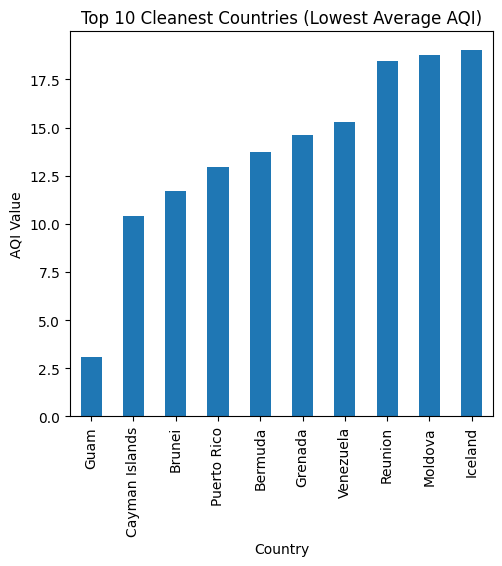

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Cleanest Countries
plt.subplot(1,2,1)
cleanest.plot(kind='bar')
plt.title("Top 10 Cleanest Countries (Lowest Average AQI)")
plt.ylabel("AQI Value")
plt.xticks(rotation=90)
plt.show()

## Top 10 polluted Countries

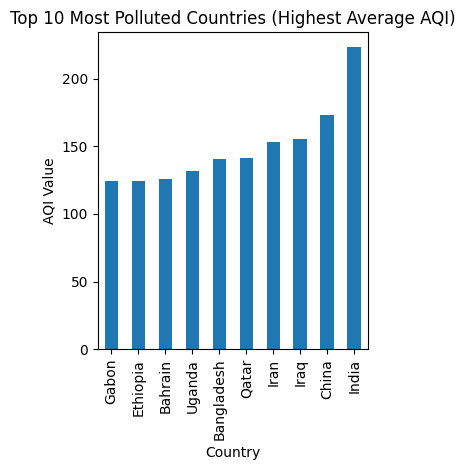

In [13]:
plt.subplot(1,2,2)
polluted.plot(kind='bar')
plt.title("Top 10 Most Polluted Countries (Highest Average AQI)")
plt.ylabel("AQI Value")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

/tmp/ipykernel_48/590093328.py:27: UserWarning: Glyph 127807 (\N{HERB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_48/590093328.py:27: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


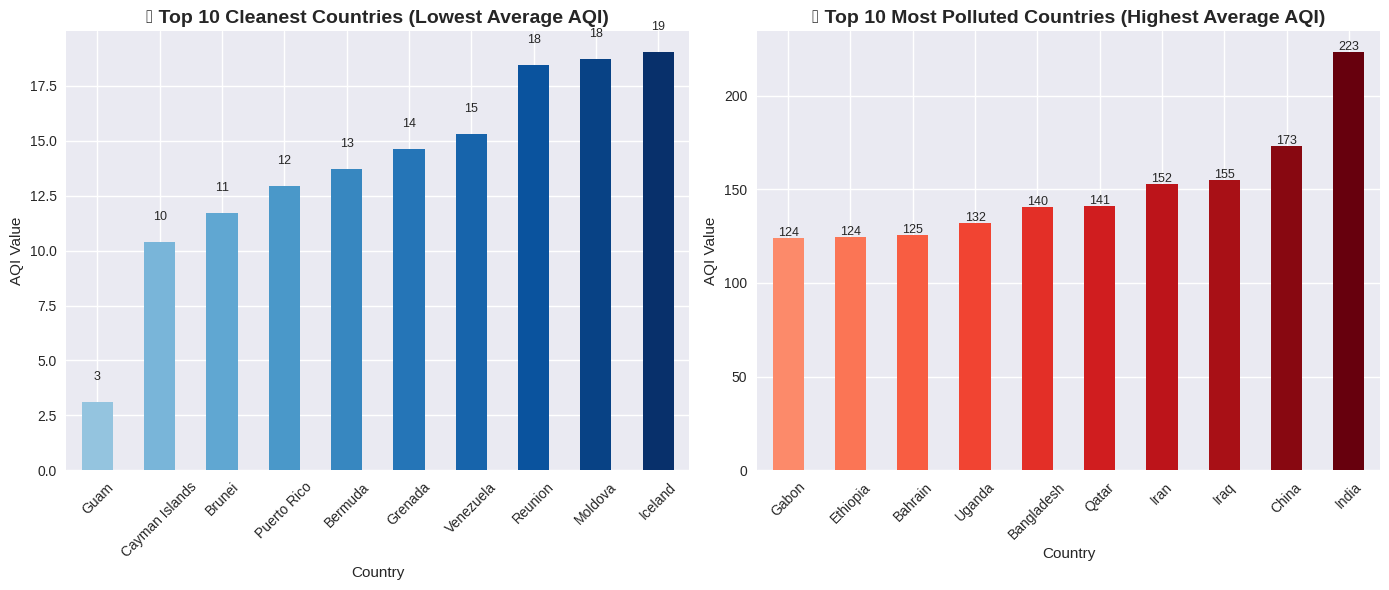

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8')  

plt.figure(figsize=(14,6))


plt.subplot(1,2,1)
cleanest.plot(kind='bar', color=plt.cm.Blues(np.linspace(0.4, 1, len(cleanest))))
plt.title("🌿 Top 10 Cleanest Countries (Lowest Average AQI)", fontsize=14, weight='bold')
plt.ylabel("AQI Value")
plt.xticks(rotation=45)
for i, v in enumerate(cleanest):
    plt.text(i, v + 1, str(int(v)), ha='center', fontsize=9)


# -------- Most Polluted Countries --------
plt.subplot(1,2,2)
polluted.plot(kind='bar', color=plt.cm.Reds(np.linspace(0.4, 1, len(polluted))))
plt.title("🔥 Top 10 Most Polluted Countries (Highest Average AQI)", fontsize=14, weight='bold')
plt.ylabel("AQI Value")
plt.xticks(rotation=45)
for i, v in enumerate(polluted):
    plt.text(i, v + 1, str(int(v)), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [15]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

/tmp/ipykernel_48/3502227431.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_48/3502227431.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_48/3502227431.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_48/3502227431.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_48/3502227431.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_48/3502227431.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_48/3502227431.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_48/3502227431.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_48/3502227431.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_48/3

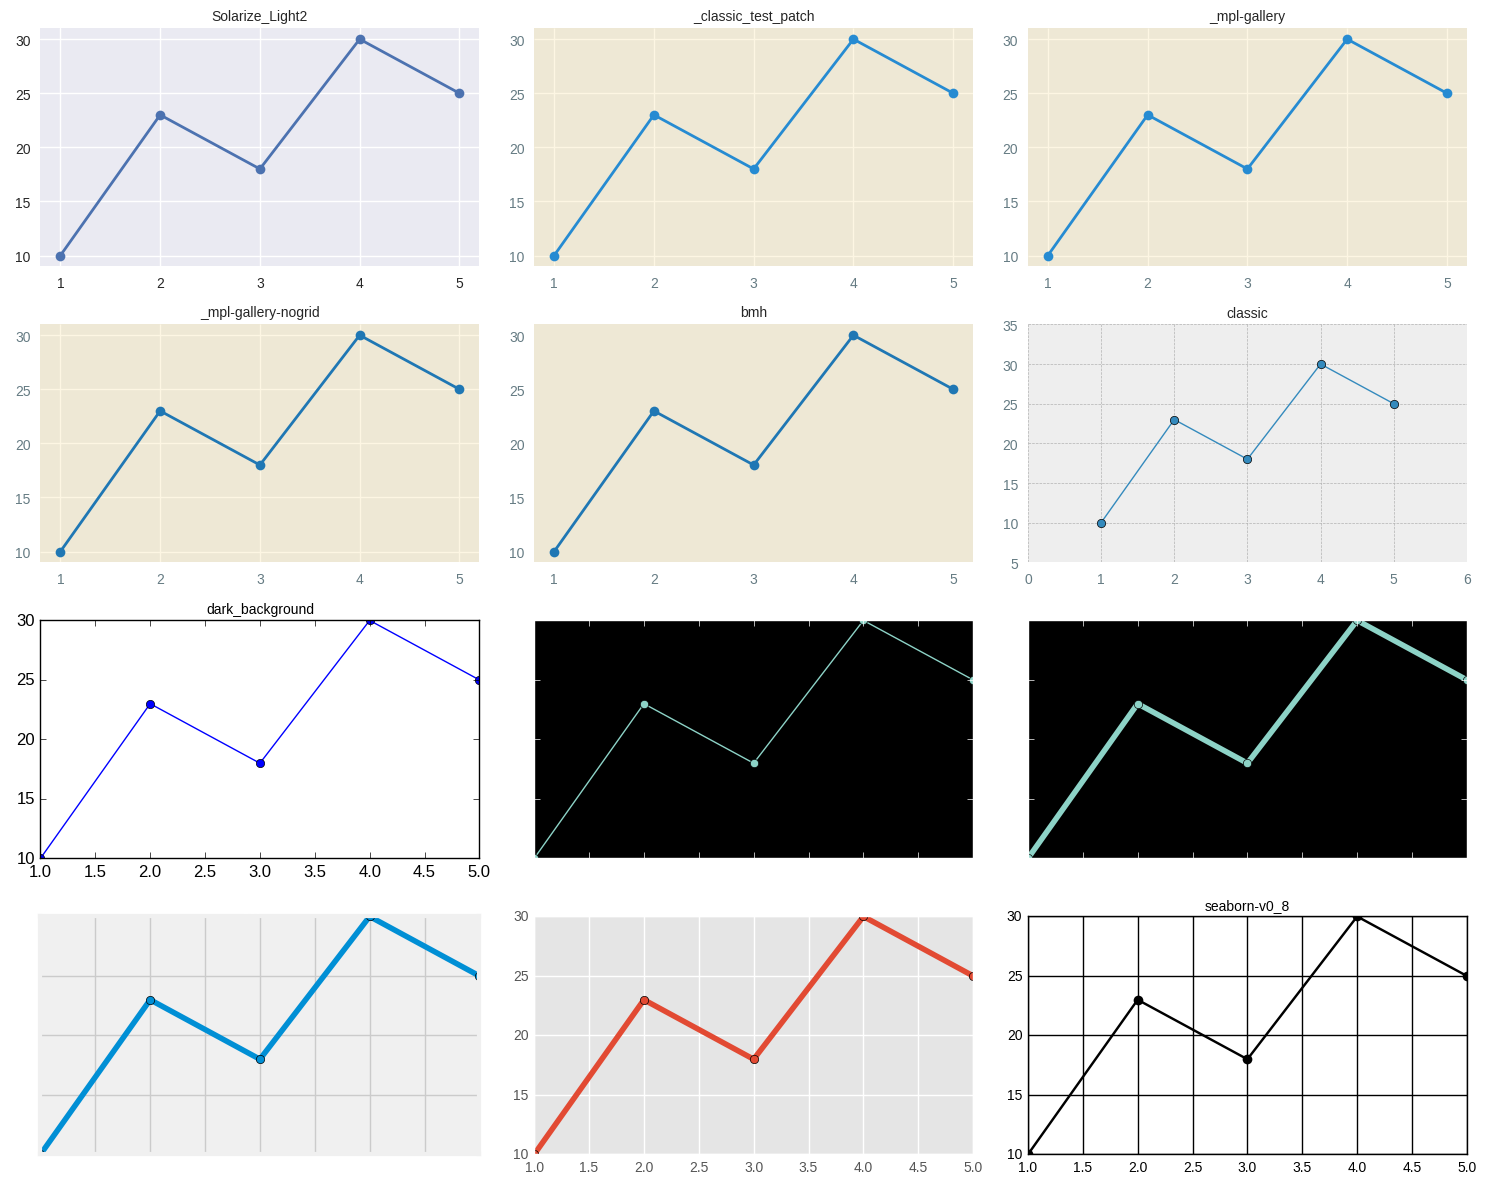

In [16]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(1, 6)
y = np.array([10, 23, 18, 30, 25])

styles = plt.style.available[:12]  # Show first 12 styles (change number if you want more)

plt.figure(figsize=(15, 12))

for i, style in enumerate(styles):
    plt.subplot(4, 3, i+1)   # 4 rows, 3 columns → adjust if changing count
    plt.style.use(style)
    plt.plot(x, y, marker='o')
    plt.title(style, fontsize=10)
    plt.tight_layout()

plt.show()


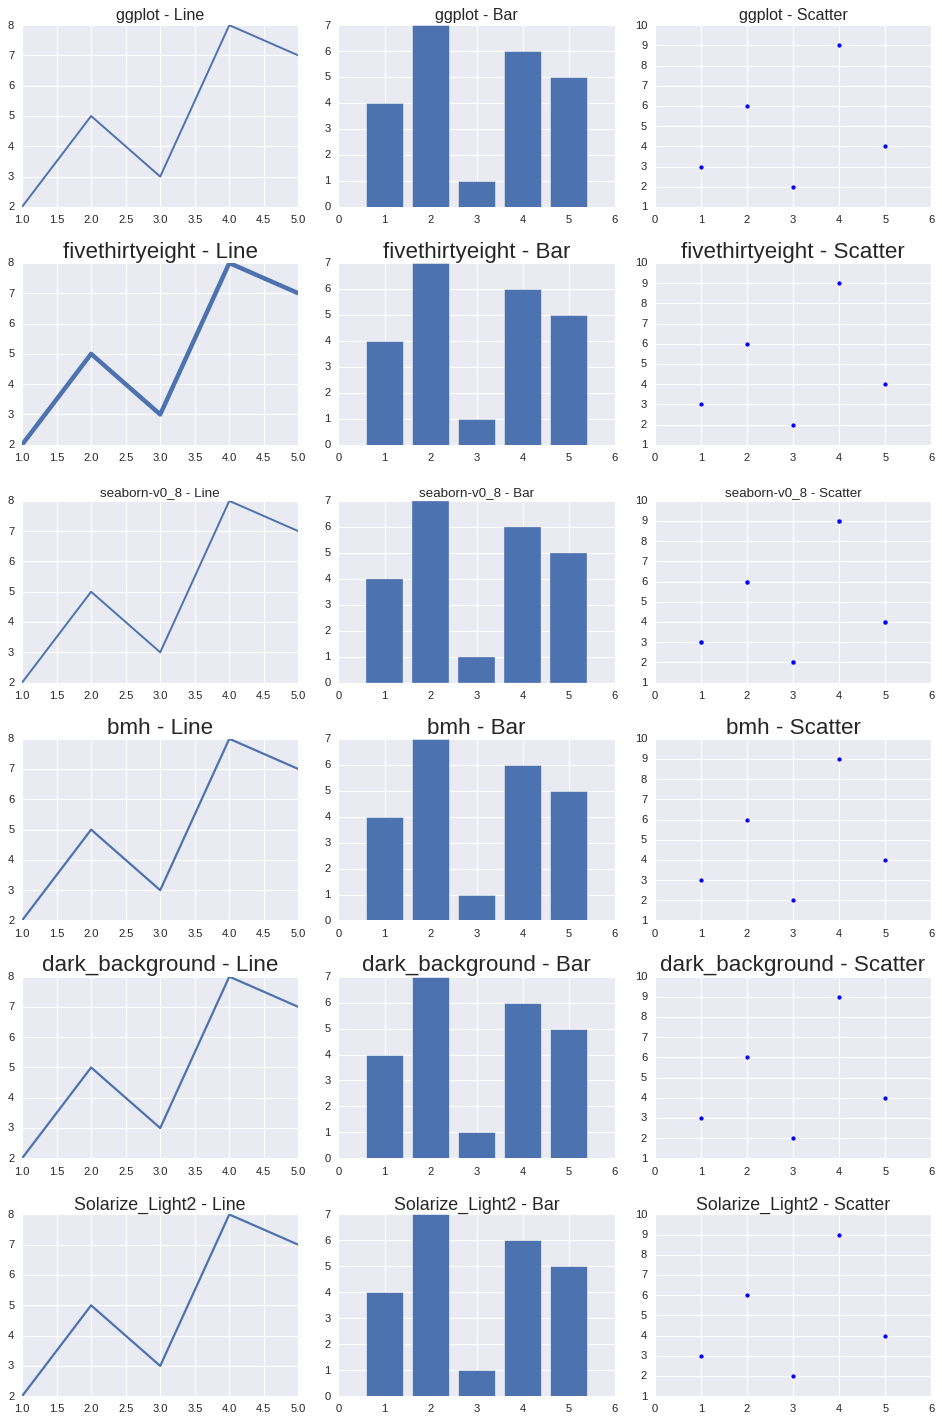

In [17]:
import matplotlib.pyplot as plt

# Sample data
x = [1, 2, 3, 4, 5]
y_line = [2, 5, 3, 8, 7]
y_bar = [4, 7, 1, 6, 5]
y_scatter = [3, 6, 2, 9, 4]

styles = ['ggplot', 'fivethirtyeight', 'seaborn-v0_8', 'bmh', 'dark_background', 'Solarize_Light2']

fig, axes = plt.subplots(len(styles), 3, figsize=(12, 18))

for i, style in enumerate(styles):
    plt.style.use(style)

    # Line
    axes[i, 0].plot(x, y_line)
    axes[i, 0].set_title(style + " - Line")

    # Bar
    axes[i, 1].bar(x, y_bar)
    axes[i, 1].set_title(style + " - Bar")

    # Scatter
    axes[i, 2].scatter(x, y_scatter)
    axes[i, 2].set_title(style + " - Scatter")

plt.tight_layout()
plt.show()


In [18]:
country_avg = df.groupby('Country')['AQI Value'].mean().sort_values()
cleanest = country_avg.head(10)
polluted = country_avg.tail(10)


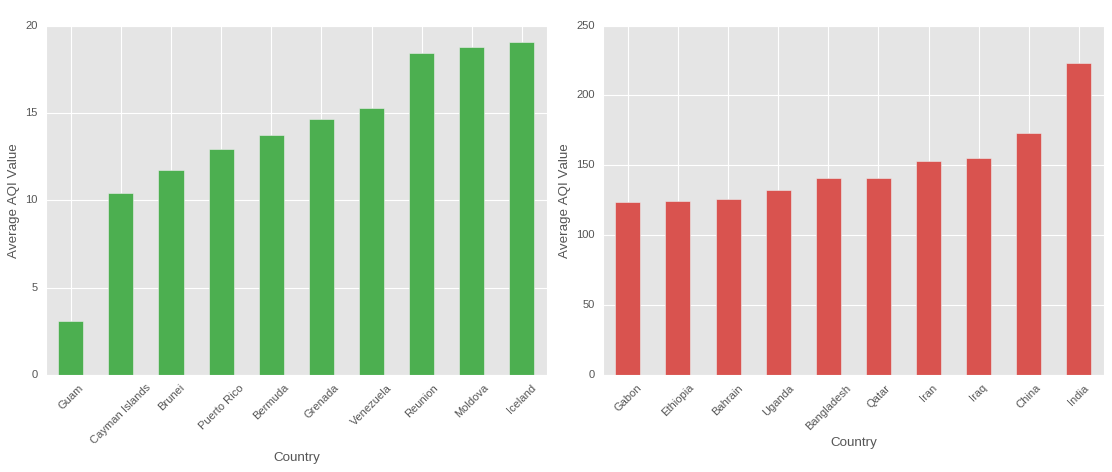

In [19]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')   

plt.figure(figsize=(14,6))

# Cleanest Countries
plt.subplot(1,2,1)
cleanest.plot(kind='bar', color='#4CAF50')
plt.title("Top 10 Cleanest Countries (Lowest Average AQI)", fontsize=14, weight='bold')
plt.ylabel("Average AQI Value")
plt.xticks(rotation=45)

# Most Polluted Countries
plt.subplot(1,2,2)
polluted.plot(kind='bar', color='#D9534F')
plt.title("Top 10 Most Polluted Countries (Highest Average AQI)", fontsize=14, weight='bold')
plt.ylabel("Average AQI Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



In [20]:
!pip install pycountry


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 68.0 MB/s eta 0:00:00:00:0100:01


In [21]:
import pycountry

def get_country_code(name):
    try:
        return pycountry.countries.lookup(name).alpha_3
    except:
        return None

df['Country_Code'] = df['Country'].apply(get_country_code)
df.head()


,Date,Country,Status,AQI Value,Country_Code
0,2022-07-21,Albania,Good,14,ALB
1,2022-07-21,Algeria,Moderate,65,DZA
2,2022-07-21,Andorra,Moderate,55,AND
3,2022-07-21,Angola,Unhealthy for Sensitive Groups,113,AGO
4,2022-07-21,Argentina,Moderate,63,ARG


In [22]:
!pip install plotly


In [23]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# Sort for clean plotting
df = df.sort_values("Date")

# List of unique countries for dropdown
countries = df["Country"].unique()

# Default country to show first
default_country = "India" if "India" in countries else countries[0]

# Filter data for default view
df_country = df[df["Country"] == default_country]

# --- Line Chart: AQI Trend Over Time
fig_line = px.line(
    df_country, 
    x="Date", 
    y="AQI Value", 
    title=f"AQI Trend Over Time - {default_country}",
    markers=True
)

fig_line.update_traces(line=dict(width=2))
fig_line.update_layout(title_font=dict(size=20), yaxis_title="AQI")

# --- Bar Chart: AQI Status Distribution ---
status_counts = df_country["Status"].value_counts().reset_index()
status_counts.columns = ["Status", "Count"]

fig_bar = px.bar(
    status_counts, 
    x="Status", 
    y="Count", 
    title=f"Air Quality Status Spread - {default_country}",
    text="Count"
)

fig_bar.update_layout(title_font=dict(size=20), yaxis_title="Number of Days")

fig_line.show()
fig_bar.show()


In [24]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def update_dashboard(selected_country):
    clear_output(wait=True)

    df_c = df[df["Country"] == selected_country]

    # Line Chart
    fig_line = px.line(df_c, x="Date", y="AQI Value", 
                       title=f"AQI Trend Over Time - {selected_country}",
                       markers=True)

    fig_line.show()

    # Bar Chart
    status_counts = df_c["Status"].value_counts().reset_index()
    status_counts.columns = ["Status", "Count"]

    fig_bar = px.bar(
        status_counts, 
        x="Status", 
        y="Count",
        title=f"Air Quality Status Spread - {selected_country}",
        text="Count"
    )

    fig_bar.show()

dropdown = widgets.Dropdown(options=countries, value=default_country, description="Country:")
widgets.interact(update_dashboard, selected_country=dropdown);


interactive(children=(Dropdown(description='Country:', index=27, options=('Albania', 'El Salvador', 'Estonia',…

In [25]:
import requests

token = "27fc826f18a3a6dbf79be841a9f279868dfb7d41"  # Replace this
city = "Delhi"

url = f"https://api.waqi.info/feed/{city}/?token={token}"
data = requests.get(url).json()

print("City:", data['data']['city']['name'])
print("AQI Today:", data['data']['aqi'])


City: Major Dhyan Chand National Stadium, Delhi, Delhi, India
AQI Today: 176


In [26]:
def get_aqi(city):
    url = f"https://api.waqi.info/feed/{city}/?token={token}"
    data = requests.get(url).json()
    return data['data']['aqi']

print("India (Delhi):", get_aqi("Delhi"))
print("USA (Washington DC):", get_aqi("Washington DC"))
print("China (Beijing):", get_aqi("Beijing"))


India (Delhi): 176
USA (Washington DC): 74
China (Beijing): 155


In [27]:
import datetime

today = datetime.date.today()

today_aqi = get_aqi("Delhi")  

new_row = {
    "Date": today,
    "Country": "India",
    "Status": None, 
    "AQI Value": today_aqi,
    "Country_Code": "IND"
}



df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)



In [28]:
def aqi_status(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Moderate"
    elif aqi <= 150: return "Unhealthy for Sensitive Groups"
    elif aqi <= 200: return "Unhealthy"
    elif aqi <= 300: return "Very Unhealthy"
    else: return "Hazardous"

df.loc[df['Status'].isna(), 'Status'] = df['AQI Value'].apply(aqi_status)


In [29]:
today_val = today_aqi
yest_val = df[(df['Country']=="India")].iloc[-2]["AQI Value"]

print("📊 Change in AQI from Yesterday:", today_val - yest_val)


📊 Change in AQI from Yesterday: -390


In [30]:
df = df.drop_duplicates(subset=["Date", "Country"], keep="last")
df.reset_index(drop=True, inplace=True)

In [31]:
import requests
import datetime
import pandas as pd

token = "27fc826f18a3a6dbf79be841a9f279868dfb7d41"
city = "Delhi"

def get_aqi(city):
    url = f"https://api.waqi.info/feed/{city}/?token={token}"
    data = requests.get(url).json()
    return data['data']['aqi']

today = datetime.date.today()
today_aqi = get_aqi(city)

new_row = {
    "Date": today,
    "Country": "India",
    "Status": None,
    "AQI Value": today_aqi,
    "Country_Code": "IND"
}

# ✅ Correct replacement for df.append()
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

# Assign Status
def aqi_status(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Moderate"
    elif aqi <= 150: return "Unhealthy for Sensitive Groups"
    elif aqi <= 200: return "Unhealthy"
    elif aqi <= 300: return "Very Unhealthy"
    else: return "Hazardous"

df.loc[df['Status'].isna(), 'Status'] = df['AQI Value'].apply(aqi_status)

print(df.tail())


                      Date      Country     Status  AQI Value Country_Code
20929  2025-11-20 00:00:00  El Salvador       Good         28          SLV
20930  2025-11-20 00:00:00       Kosovo   Moderate         61         None
20931  2025-11-20 00:00:00      Vietnam   Moderate         58          VNM
20932           2025-11-22        India  Unhealthy        176          IND
20933           2025-11-22        India  Unhealthy        176          IND


In [32]:
from tabulate import tabulate
print(tabulate(df.tail(5), headers='keys', tablefmt='github'))


|       | Date                | Country     | Status    |   AQI Value | Country_Code   |
|-------|---------------------|-------------|-----------|-------------|----------------|
| 20929 | 2025-11-20 00:00:00 | El Salvador | Good      |          28 | SLV            |
| 20930 | 2025-11-20 00:00:00 | Kosovo      | Moderate  |          61 |                |
| 20931 | 2025-11-20 00:00:00 | Vietnam     | Moderate  |          58 | VNM            |
| 20932 | 2025-11-22          | India       | Unhealthy |         176 | IND            |
| 20933 | 2025-11-22          | India       | Unhealthy |         176 | IND            |


In [33]:
import pycountry

def get_country_code(name):
    try:
        return pycountry.countries.get(name=name).alpha_3
    except:
        return None

df["Country_Code"] = df["Country"].apply(get_country_code)


In [34]:
avg_aqi = df.groupby(["Country", "Country_Code"])["AQI Value"].mean().reset_index()

In [35]:
import plotly.express as px

fig = px.choropleth(
    avg_aqi,
    locations="Country_Code",
    color="AQI Value",
    hover_name="Country",
    color_continuous_scale="RdYlGn_r",
    title="🌍 Global Average Air Quality Index (AQI) by Country"
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    title_font=dict(size=22)
)

fig.show()


In [36]:
import pandas as pd

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [37]:
df['Country'].unique()
df.groupby('Date')['Country'].nunique().sort_values(ascending=False).head(10)


Date
2022-07-21    142
2022-08-15    141
2022-09-13    141
2022-08-18    141
2022-08-19    141
2022-08-20    141
2022-08-21    141
2022-08-22    141
2022-08-23    141
2022-08-24    141
Name: Country, dtype: int64

In [38]:
today = df['Date'].max()   # latest date in dataset (Timestamp)

today_aqi_map = df[df['Date'] == today]

fig = px.choropleth(
    today_aqi_map,
    locations="Country_Code",
    color="AQI Value",
    hover_name="Country",
    color_continuous_scale="RdYlGn_r",
    title=f"🌍 World Air Quality Map on {today.date()}"
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    title_font=dict(size=22)
)

fig.show()


In [39]:
df.head()


,Date,Country,Status,AQI Value,Country_Code
0,2022-07-21,Albania,Good,17,ALB
1,2022-07-21,Vietnam,Good,43,None
2,2022-07-21,Egypt,Moderate,86,EGY
3,2022-07-21,El Salvador,Moderate,80,SLV
4,2022-07-21,Estonia,Good,15,EST


In [40]:
import requests

token = "27fc826f18a3a6dbf79be841a9f279868dfb7d41"
city = "Delhi"

url = f"https://api.waqi.info/feed/{city}/?token={token}"
data = requests.get(url).json()

print("City:", data['data']['city']['name'])
print("AQI Today:", data['data']['aqi'])


City: Major Dhyan Chand National Stadium, Delhi, Delhi, India
AQI Today: 176


In [41]:
import requests
import pandas as pd

token = "27fc826f18a3a6dbf79be841a9f279868dfb7d41"

indian_cities = {
    "Delhi": "Delhi",
    "Maharashtra": "Mumbai",
    "Uttar Pradesh": "Lucknow",
    "West Bengal": "Kolkata",
    "Tamil Nadu": "Chennai",
    "Karnataka": "Bengaluru",
    "Telangana": "Hyderabad",
    "Gujarat": "Ahmedabad",
    "Rajasthan": "Jaipur",
    "Punjab": "Chandigarh",
    "Bihar": "Patna",
    "Madhya Pradesh": "Bhopal",
    "Odisha": "Bhubaneswar",
    "Kerala": "Thiruvananthapuram",
    "Assam": "Guwahati",
    "Jharkhand": "Ranchi",
    "Chhattisgarh": "Raipur",
    "Haryana": "Gurugram",
    "Jammu & Kashmir": "Srinagar",
}

aqi_rows = []

for state, city in indian_cities.items():
    url = f"https://api.waqi.info/feed/{city}/?token={token}"
    response = requests.get(url).json()
    
    if response["status"] == "ok":
        aqi_value = response["data"]["aqi"]
    else:
        aqi_value = None  # If API fails
    
    aqi_rows.append([state, city, aqi_value])

df_india = pd.DataFrame(aqi_rows, columns=["State", "City", "AQI"])
df_india


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning:

invalid value encountered in greater

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in less

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in greater



,State,City,AQI
0,Delhi,Delhi,176.0
1,Maharashtra,Mumbai,152.0
2,Uttar Pradesh,Lucknow,154.0
3,West Bengal,Kolkata,172.0
4,Tamil Nadu,Chennai,35.0
5,Karnataka,Bengaluru,52.0
6,Telangana,Hyderabad,99.0
7,Gujarat,Ahmedabad,121.0
8,Rajasthan,Jaipur,144.0
9,Punjab,Chandigarh,172.0


In [42]:
import plotly.express as px

fig = px.bar(
    df_india,
    x="State",
    y="AQI",
    text="AQI",
    title="🇮🇳 Today's Air Quality Index (AQI) by Indian States",
    labels={"AQI": "Air Quality Index"},
)

fig.update_traces(textposition="outside")
fig.update_layout(xaxis_tickangle=-45)
fig.show()


In [43]:
import requests
import pandas as pd

token = "27fc826f18a3a6dbf79be841a9f279868dfb7d41"

# World capitals (short list, you can expand)
world_capitals = {
    "India": ("Delhi", "IND"),
    "USA": ("Washington DC", "USA"),
    "China": ("Beijing", "CHN"),
    "Japan": ("Tokyo", "JPN"),
    "UK": ("London", "GBR"),
    "Germany": ("Berlin", "DEU"),
    "France": ("Paris", "FRA"),
    "Canada": ("Ottawa", "CAN"),
    "Australia": ("Canberra", "AUS"),
    "Russia": ("Moscow", "RUS"),
    "Brazil": ("Brasilia", "BRA"),
    "South Korea": ("Seoul", "KOR"),
}

def get_aqi(city):
    try:
        url = f"https://api.waqi.info/feed/{city}/?token={token}"
        data = requests.get(url).json()
        return data['data']['aqi']
    except:
        return None

world_aqi = []

for country, (city, code) in world_capitals.items():
    aqi = get_aqi(city)
    world_aqi.append([country, city, code, aqi])

df_world = pd.DataFrame(world_aqi, columns=["Country", "City", "Code", "AQI"])
df_world



,Country,City,Code,AQI
0,India,Delhi,IND,176
1,USA,Washington DC,USA,74
2,China,Beijing,CHN,155
3,Japan,Tokyo,JPN,34
4,UK,London,GBR,38
5,Germany,Berlin,DEU,63
6,France,Paris,FRA,97
7,Canada,Ottawa,CAN,10
8,Australia,Canberra,AUS,8
9,Russia,Moscow,RUS,42


In [44]:
import plotly.express as px

fig = px.choropleth(
    df_world,
    locations="Code",
    color="AQI",
    hover_name="Country",
    hover_data=["City", "AQI"],
    color_continuous_scale="RdYlGn_r",
    title="🌎 Live Global AQI (by Capital Cities)",
)

fig.show()


In [45]:
india_cities = {
    "Delhi": "Delhi",
    "Maharashtra": "Mumbai",
    "Uttar Pradesh": "Lucknow",
    "West Bengal": "Kolkata",
    "Tamil Nadu": "Chennai",
    "Karnataka": "Bengaluru",
    "Telangana": "Hyderabad",
    "Gujarat": "Ahmedabad",
    "Rajasthan": "Jaipur",
    "Punjab": "Chandigarh",
    "Bihar": "Patna",
    "Madhya Pradesh": "Bhopal",
    "Odisha": "Bhubaneswar",
    "Kerala": "Thiruvananthapuram",
    "Assam": "Guwahati",
    "Jharkhand": "Ranchi",
    "Chhattisgarh": "Raipur",
    "Haryana": "Gurugram",
    "Jammu & Kashmir": "Srinagar",
}

india_aqi = []

for state, city in india_cities.items():
    aqi = get_aqi(city)
    india_aqi.append([state, city, aqi])

df_india = pd.DataFrame(india_aqi, columns=["State", "City", "AQI"])
df_india


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning:

invalid value encountered in greater

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in less

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in greater



,State,City,AQI
0,Delhi,Delhi,176.0
1,Maharashtra,Mumbai,152.0
2,Uttar Pradesh,Lucknow,154.0
3,West Bengal,Kolkata,172.0
4,Tamil Nadu,Chennai,35.0
5,Karnataka,Bengaluru,52.0
6,Telangana,Hyderabad,99.0
7,Gujarat,Ahmedabad,121.0
8,Rajasthan,Jaipur,144.0
9,Punjab,Chandigarh,172.0


In [46]:
fig_bar = px.bar(
    df_india,
    x="State",
    y="AQI",
    text="AQI",
    color="AQI",
    color_continuous_scale="RdYlGn_r",
    title="🇮🇳 Live AQI by Indian States (Major City Represented)"
)

fig_bar.update_layout(xaxis_tickangle=45)
fig_bar.update_traces(textposition='outside')
fig_bar.show()


In [47]:
import pandas as pd

df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")
df.head(100)


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Assam,Nalbari,"Bata Chowk, Nalbari - PCBA",21-11-2025 22:00:00,26.446912,91.439057,SO2,6.0,8.0,8.0
1,India,Assam,Silchar,"Tarapur, Silchar - PCBA",21-11-2025 22:00:00,24.828270,92.795250,PM10,41.0,58.0,47.0
2,India,Assam,Silchar,"Tarapur, Silchar - PCBA",21-11-2025 22:00:00,24.828270,92.795250,NH3,1.0,1.0,1.0
3,India,Assam,Silchar,"Tarapur, Silchar - PCBA",21-11-2025 22:00:00,24.828270,92.795250,CO,34.0,75.0,66.0
4,India,Assam,Sivasagar,"Girls College, Sivasagar - PCBA",21-11-2025 22:00:00,26.987634,94.636574,PM10,27.0,95.0,49.0
...,...,...,...,...,...,...,...,...,...,...,...
95,India,Bihar,Muzaffarpur,"Buddha Colony, Muzaffarpur - BSPCB",21-11-2025 22:00:00,26.114420,85.398130,OZONE,15.0,116.0,51.0
96,India,Bihar,Muzaffarpur,"MIT-Daudpur Kothi, Muzaffarpur - BSPCB",21-11-2025 22:00:00,26.140335,85.365019,NH3,1.0,1.0,1.0
97,India,Delhi,Delhi,"Vivek Vihar, Delhi - DPCC",21-11-2025 22:00:00,28.672342,77.315260,NH3,12.0,15.0,13.0
98,India,Delhi,Delhi,"Vivek Vihar, Delhi - DPCC",21-11-2025 22:00:00,28.672342,77.315260,SO2,8.0,26.0,14.0


In [48]:
df["value"] = (df["pollutant_min"] + df["pollutant_max"]) / 2

# FIX NaN values
df["value"] = df["value"].fillna(0)


In [49]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# Calculate pollution value as average
df["value"] = (df["pollutant_min"] + df["pollutant_max"]) / 2

# Fix missing values
df["value"] = df["value"].fillna(0)

# Clip extremely large values (optional but prevents huge bubbles)
df["value"] = df["value"].clip(lower=1, upper=300)

# PLOT
fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    color="value",
    hover_name="city",
    hover_data=["station", "pollutant_id", "pollutant_min", "pollutant_max"],
    color_continuous_scale="Inferno",
    size="value",
    size_max=20,
    zoom=4,
    height=800,
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="MAP 1 — India Air Pollution (Station-Level Bubble Map)",
    margin={"r":0, "t":40, "l":0, "b":0}
)

fig.show()


In [50]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# pollution value
df["value"] = (df["pollutant_min"] + df["pollutant_max"]) / 2

# remove NaN and zeros (very important)
df = df.dropna(subset=["latitude", "longitude", "value"])
df = df[df["value"] > 0]

# remove impossible coordinates
df = df[(df["latitude"] >= 6) & (df["latitude"] <= 38)]
df = df[(df["longitude"] >= 68) & (df["longitude"] <= 98)]

fig = px.density_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    z="value",
    radius=20,
    center=dict(lat=22.5, lon=79.0),
    zoom=4,
    mapbox_style="open-street-map",
    color_continuous_scale="Inferno",
    height=800
)

fig.update_layout(
    title="India Pollution Heatmap (Working Version)",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


# 3A — PM2.5 Map

In [51]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# Pollution value
df["value"] = (df["pollutant_min"] + df["pollutant_max"]) / 2

# Filter PM2.5
pm25 = df[df["pollutant_id"] == "PM2.5"]
pm25 = pm25.dropna(subset=["latitude", "longitude", "value"])
pm25 = pm25[pm25["value"] > 0]

fig = px.scatter_mapbox(
    pm25,
    lat="latitude",
    lon="longitude",
    color="value",
    size="value",
    hover_name="city",
    hover_data=["station", "pollutant_min", "pollutant_max"],
    color_continuous_scale="Inferno",
    size_max=20,
    zoom=4,
    height=800
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="MAP 3A — PM2.5 Pollution Across India",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


# 3B — PM10 Map

In [52]:
pm10 = df[df["pollutant_id"] == "PM10"]
pm10 = pm10.dropna(subset=["latitude", "longitude", "value"])
pm10 = pm10[pm10["value"] > 0]

fig = px.scatter_mapbox(
    pm10,
    lat="latitude",
    lon="longitude",
    color="value",
    size="value",
    hover_name="city",
    hover_data=["station", "pollutant_min", "pollutant_max"],
    color_continuous_scale="Inferno",
    size_max=20,
    zoom=4,
    height=800
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="MAP 3B — PM10 Pollution Across India",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


# 3C — SO₂ Map

In [53]:
so2 = df[df["pollutant_id"] == "SO2"]
so2 = so2.dropna(subset=["latitude", "longitude", "value"])
so2 = so2[so2["value"] > 0]

fig = px.scatter_mapbox(
    so2,
    lat="latitude",
    lon="longitude",
    color="value",
    size="value",
    hover_name="city",
    hover_data=["station", "pollutant_min", "pollutant_max"],
    color_continuous_scale="Inferno",
    size_max=20,
    zoom=4,
    height=800
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="MAP 3C — SO₂ Levels Across India",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


# 3D — NO₂ Map

In [54]:
no2 = df[df["pollutant_id"] == "NO2"]
no2 = no2.dropna(subset=["latitude", "longitude", "value"])
no2 = no2[no2["value"] > 0]

fig = px.scatter_mapbox(
    no2,
    lat="latitude",
    lon="longitude",
    color="value",
    size="value",
    hover_name="city",
    hover_data=["station", "pollutant_min", "pollutant_max"],
    color_continuous_scale="Inferno",
    size_max=20,
    zoom=4,
    height=800
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="MAP 3D — NO₂ Levels Across India",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


# 3E — OZONE Map

In [55]:
ozone = df[df["pollutant_id"] == "OZONE"]
ozone = ozone.dropna(subset=["latitude", "longitude", "value"])
ozone = ozone[ozone["value"] > 0]

fig = px.scatter_mapbox(
    ozone,
    lat="latitude",
    lon="longitude",
    color="value",
    size="value",
    hover_name="city",
    hover_data=["station", "pollutant_min", "pollutant_max"],
    color_continuous_scale="Inferno",
    size_max=20,
    zoom=4,
    height=800
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="MAP 3E — Ozone Levels Across India",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


# 3F — CO Map

In [56]:
co = df[df["pollutant_id"] == "CO"]
co = co.dropna(subset=["latitude", "longitude", "value"])
co = co[co["value"] > 0]

fig = px.scatter_mapbox(
    co,
    lat="latitude",
    lon="longitude",
    color="value",
    size="value",
    hover_name="city",
    hover_data=["station", "pollutant_min", "pollutant_max"],
    color_continuous_scale="Inferno",
    size_max=20,
    zoom=4,
    height=800
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="MAP 3F — CO Levels Across India",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


# 3G — NH₃ Map

In [57]:
nh3 = df[df["pollutant_id"] == "NH3"]
nh3 = nh3.dropna(subset=["latitude", "longitude", "value"])
nh3 = nh3[nh3["value"] > 0]

fig = px.scatter_mapbox(
    nh3,
    lat="latitude",
    lon="longitude",
    color="value",
    size="value",
    hover_name="city",
    hover_data=["station", "pollutant_min", "pollutant_max"],
    color_continuous_scale="Inferno",
    size_max=20,
    zoom=4,
    height=800
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="MAP 3G — NH₃ Levels Across India",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


In [58]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# pollution value
df["value"] = (df["pollutant_min"] + df["pollutant_max"]) / 2
df["value"] = df["value"].fillna(0)
df = df[df["value"] > 0]


In [59]:
state_aqi = df.groupby("state")["value"].mean().reset_index()
state_aqi = df.groupby("state")["value"].max().reset_index()
state_coords = df.groupby("state")[["latitude", "longitude"]].mean().reset_index()
state_map = state_aqi.merge(state_coords, on="state")


In [60]:
fig = px.scatter_mapbox(
    state_map,
    lat="latitude",
    lon="longitude",
    size="value",
    color="value",
    hover_name="state",
    hover_data={"latitude":False, "longitude":False},
    color_continuous_scale="Inferno",
    size_max=50,
    zoom=4,
    height=800
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="MAP 4 — State-Level Air Pollution Across India (No GeoJSON)",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


In [61]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# Convert date column to datetime
df["last_update"] = pd.to_datetime(df["last_update"], errors="coerce")

# pollution value
df["value"] = (df["pollutant_min"] + df["pollutant_max"]) / 2
df = df.dropna(subset=["latitude", "longitude", "value", "last_update"])
df = df[df["value"] > 0]

# Fix coordinates (India bounds)
df = df[(df["latitude"] >= 6) & (df["latitude"] <= 38)]
df = df[(df["longitude"] >= 68) & (df["longitude"] <= 98)]
df_day = df.groupby(["city", "state", "last_update"]).agg({
    "latitude":"mean",
    "longitude":"mean",
    "value":"mean"
}).reset_index()


/tmp/ipykernel_48/1937437746.py:7: UserWarning:

Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



In [62]:
fig = px.scatter_mapbox(
    df_day,
    lat="latitude",
    lon="longitude",
    size="value",
    color="value",
    hover_name="city",
    hover_data=["state", "value"],
    animation_frame="last_update",
    color_continuous_scale="Turbo",
    size_max=40,
    zoom=4,
    height=800
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="MAP 5 — Animated India Pollution Map (Day-by-Day)",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


In [63]:
# MAP 6 — Pollution vs Daily Average Temperature (Open-Meteo)
# Run this in your Kaggle notebook.

import pandas as pd
import requests
import time
import math
import plotly.express as px
from tqdm import tqdm
from pathlib import Path

# ---------- CONFIG ----------
INPUT_CSV = "/kaggle/input/india-dataset/indiaAQI.csv"   # your uploaded file
CACHE_FILE = "/kaggle/working/city_date_temp_cache.csv"  # local cache (will be created)
SLEEP_BETWEEN_CALLS = 0.45  # seconds (be polite to the API)
TIMEZONE = "Asia/Kolkata"    # timezone for daily aggregation
# ----------------------------

# 1) Load dataset
df = pd.read_csv(INPUT_CSV)

# 2) Prepare 'value' (pollution) and date
df["value"] = (pd.to_numeric(df["pollutant_min"], errors="coerce") +
               pd.to_numeric(df["pollutant_max"], errors="coerce")) / 2

df["last_update"] = pd.to_datetime(df["last_update"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude", "last_update"])
df["date"] = df["last_update"].dt.date

# 3) Aggregate to one record per city + date (mean pollutant & mean coords)
agg = df.groupby(["country", "state", "city", "date"]).agg({
    "latitude": "mean",
    "longitude": "mean",
    "value": "mean"
}).reset_index()

# remove invalid coords & values
agg = agg.dropna(subset=["latitude", "longitude", "value"])
agg = agg[(agg["latitude"].between(6, 38)) & (agg["longitude"].between(68, 98))]
agg = agg[agg["value"] > 0].reset_index(drop=True)

print(f"Unique city-date records to fetch temp for: {len(agg)}")

# 4) Load cache if exists (prevents repeated API calls)
cache_path = Path(CACHE_FILE)
if cache_path.exists():
    cache = pd.read_csv(CACHE_FILE, parse_dates=["date"])
    cache["date"] = cache["date"].dt.date
else:
    cache = pd.DataFrame(columns=["city", "state", "date", "latitude", "longitude", "temp_daily_mean"])

# helper to look up cache
def lookup_cache(city, state, date):
    r = cache[(cache["city"] == city) & (cache["state"] == state) & (cache["date"] == pd.to_datetime(date).date())]
    if not r.empty:
        return float(r.iloc[0]["temp_daily_mean"])
    return None

# 5) Function to fetch daily mean temperature using Open-Meteo ERA5 archive
def fetch_daily_mean_temp(lat, lon, date_str):
    """
    date_str: YYYY-MM-DD
    Returns float temperature (°C) or None
    """
    base = "https://archive-api.open-meteo.com/v1/era5"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": date_str,
        "end_date": date_str,
        "daily": "temperature_2m_mean",
        "timezone": TIMEZONE
    }
    try:
        r = requests.get(base, params=params, timeout=20)
        r.raise_for_status()
        j = r.json()
        # defensive checks
        if "daily" in j and "temperature_2m_mean" in j["daily"]:
            vals = j["daily"]["temperature_2m_mean"]
            if isinstance(vals, list) and len(vals) > 0:
                return float(vals[0])
    except Exception as e:
        # print(f"API error for {lat},{lon} {date_str}: {e}")
        return None
    return None

# 6) Iterate and fetch (with caching)
new_cache_rows = []
for idx, row in tqdm(agg.iterrows(), total=len(agg), desc="Fetching temps"):
    city = row["city"]
    state = row["state"]
    date_val = row["date"]
    lat = float(row["latitude"])
    lon = float(row["longitude"])

    cached = lookup_cache(city, state, date_val)
    if cached is not None:
        temp = cached
    else:
        date_str = pd.to_datetime(date_val).strftime("%Y-%m-%d")
        temp = fetch_daily_mean_temp(lat, lon, date_str)
        # cache result even if None to avoid repeating failing calls
        new_cache_rows.append({
            "city": city,
            "state": state,
            "date": date_val,
            "latitude": lat,
            "longitude": lon,
            "temp_daily_mean": temp
        })
        time.sleep(SLEEP_BETWEEN_CALLS)

# 7) Update cache file (append new rows)
if new_cache_rows:
    new_df = pd.DataFrame(new_cache_rows)
    if cache_path.exists():
        combined = pd.concat([cache, new_df], ignore_index=True)
    else:
        combined = new_df
    # save with date column as iso format
    combined["date"] = pd.to_datetime(combined["date"])
    combined.to_csv(CACHE_FILE, index=False)
    cache = combined
    cache["date"] = cache["date"].dt.date

# 8) Merge temperatures back into aggregated data
agg["date"] = pd.to_datetime(agg["date"]).dt.date
agg = agg.merge(
    cache[["city", "state", "date", "temp_daily_mean"]],
    how="left",
    left_on=["city", "state", "date"],
    right_on=["city", "state", "date"]
)

missing = agg["temp_daily_mean"].isna().sum()
print(f"Missing temperature values after API/caching: {missing}")

# 9) Final plotting (only rows with temperature)
plot_df = agg.dropna(subset=["temp_daily_mean"]).copy()
plot_df["temp_daily_mean"] = plot_df["temp_daily_mean"].astype(float)

# Clip pollution for display
plot_df["value_clip"] = plot_df["value"].clip(lower=1, upper=300)

fig = px.scatter_mapbox(
    plot_df,
    lat="latitude",
    lon="longitude",
    color="temp_daily_mean",
    size="value_clip",
    hover_name="city",
    hover_data=["state", "date", "value", "temp_daily_mean"],
    color_continuous_scale="thermal",
    size_max=30,
    zoom=4,
    height=800
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="Pollution (bubble size) vs Daily Avg Temperature (bubble color)",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


/tmp/ipykernel_48/2164025200.py:26: UserWarning:

Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



Unique city-date records to fetch temp for: 255


Fetching temps: 100%|██████████| 255/255 [06:22<00:00,  1.50s/it]

Missing temperature values after API/caching: 0


In [64]:
# SAVE MERGED POLLUTION + TEMPERATURE DATA (FINAL CSV)

import pandas as pd
import requests
import time
from tqdm import tqdm
from pathlib import Path

INPUT_CSV = "/kaggle/input/india-dataset/indiaAQI.csv"
CACHE_FILE = "/kaggle/working/temp_cache.csv"

df = pd.read_csv(INPUT_CSV)

# Pollution value
df["value"] = (pd.to_numeric(df["pollutant_min"], errors="coerce") + 
               pd.to_numeric(df["pollutant_max"], errors="coerce")) / 2
df["last_update"] = pd.to_datetime(df["last_update"], errors="coerce")
df["date"] = df["last_update"].dt.date
df = df.dropna(subset=["latitude", "longitude", "value", "date"])
df = df[df["value"] > 0]

# Aggregate to city-date
agg = df.groupby(["state", "city", "date"]).agg({
    "latitude": "mean",
    "longitude": "mean",
    "value": "mean"
}).reset_index()

# Load or create cache
cache_path = Path(CACHE_FILE)
if cache_path.exists():
    cache = pd.read_csv(CACHE_FILE, parse_dates=["date"])
    cache["date"] = cache["date"].dt.date
else:
    cache = pd.DataFrame(columns=["state", "city", "date", "temp"])

def get_cached(state, city, date):
    r = cache[(cache["state"] == state) &
              (cache["city"] == city) &
              (cache["date"] == date)]
    return None if r.empty else float(r.iloc[0]["temp"])

# API call
def fetch_temp(lat, lon, date_str):
    url = "https://archive-api.open-meteo.com/v1/era5"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": date_str,
        "end_date": date_str,
        "daily": "temperature_2m_mean",
        "timezone": "Asia/Kolkata"
    }
    try:
        resp = requests.get(url, params=params, timeout=15).json()
        return resp["daily"]["temperature_2m_mean"][0]
    except:
        return None

new_rows = []
for i, row in tqdm(agg.iterrows(), total=len(agg)):
    state = row["state"]
    city = row["city"]
    date = row["date"]
    lat = float(row["latitude"])
    lon = float(row["longitude"])
    date_str = pd.to_datetime(date).strftime("%Y-%m-%d")

    cached = get_cached(state, city, date)
    if cached is not None:
        temp = cached
    else:
        temp = fetch_temp(lat, lon, date_str)
        new_rows.append({
            "state": state,
            "city": city,
            "date": date,
            "temp": temp
        })
        time.sleep(0.5)

# Update cache
if new_rows:
    new_cache = pd.DataFrame(new_rows)
    cache = pd.concat([cache, new_cache], ignore_index=True)
    cache["date"] = pd.to_datetime(cache["date"])
    cache.to_csv(CACHE_FILE, index=False)

# Merge temperature
cache["date"] = cache["date"].dt.date
agg = agg.merge(cache, on=["state", "city", "date"], how="left")

# Final output CSV
OUTPUT_CSV = "/kaggle/working/indiaAQI_with_temperature.csv"
agg.to_csv(OUTPUT_CSV, index=False)

print("DONE! File saved to:", OUTPUT_CSV)

/tmp/ipykernel_48/805612512.py:17: UserWarning:

Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.

100%|██████████| 255/255 [06:46<00:00,  1.59s/it]

DONE! File saved to: /kaggle/working/indiaAQI_with_temperature.csv



/tmp/ipykernel_48/805612512.py:85: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [65]:
# MAP 7 — KMeans Clustered Pollution Zones in India

import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans
import numpy as np

# Load your dataset
df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# Pollution value
df["value"] = (pd.to_numeric(df["pollutant_min"], errors="ignore") +
               pd.to_numeric(df["pollutant_max"], errors="ignore")) / 2

# Clean data
df["last_update"] = pd.to_datetime(df["last_update"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude", "value"])
df = df[df["value"] > 0]

# Compute daily mean per city
df["date"] = df["last_update"].dt.date

city_df = df.groupby(["state", "city"]).agg({
    "latitude": "mean",
    "longitude": "mean",
    "value": "mean"
}).reset_index()

# Normalize pollution for clustering
X = city_df[["value"]].values

# KMeans clustering (3 zones: low, medium, high)
kmeans = KMeans(n_clusters=3, random_state=42)
city_df["cluster"] = kmeans.fit_predict(X)

# Sort clusters based on pollution level (so 0 = low, 2 = high)
cluster_order = city_df.groupby("cluster")["value"].mean().sort_values().index.tolist()
mapping = {old:new for new, old in enumerate(cluster_order)}
city_df["cluster"] = city_df["cluster"].map(mapping)

# Nice labels
cluster_labels = {
    0: "Low Pollution Zone",
    1: "Moderate Pollution Zone",
    2: "High Pollution Zone"
}
city_df["cluster_label"] = city_df["cluster"].map(cluster_labels)

# Plot cluster map
fig = px.scatter_mapbox(
    city_df,
    lat="latitude",
    lon="longitude",
    color="cluster_label",
    hover_name="city",
    hover_data=["state", "value"],
    size="value",
    size_max=30,
    zoom=4,
    height=800,
    color_discrete_sequence=["green", "orange", "red"]
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="KMeans Pollution Clusters",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


/tmp/ipykernel_48/1067924077.py:12: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/tmp/ipykernel_48/1067924077.py:13: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/tmp/ipykernel_48/1067924077.py:16: UserWarning:

Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



In [66]:
# MAP 8 — AQI Category Map (Good / Moderate / Poor / Very Poor / Severe)

import pandas as pd
import plotly.express as px
import numpy as np

# Load dataset
df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# Compute pollution index
df["value"] = (pd.to_numeric(df["pollutant_min"], errors="coerce") + 
               pd.to_numeric(df["pollutant_max"], errors="coerce")) / 2

df = df.dropna(subset=["longitude","latitude","value"])
df = df[df["value"] > 0]

# AQI category function
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

# Apply category
df["AQI_Category"] = df["value"].apply(categorize_aqi)

# Color map for category
color_map = {
    "Good": "green",
    "Satisfactory": "lightgreen",
    "Moderate": "yellow",
    "Poor": "orange",
    "Very Poor": "red",
    "Severe": "darkred"
}

# Plot AQI Category Map
fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    color="AQI_Category",
    hover_name="city",
    hover_data=["state","station","value"],
    color_discrete_map=color_map,
    size="value",
    size_max=25,
    zoom=4,
    height=800
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="MAP 8 — India AQI Category Map (Good → Severe)",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


In [67]:
# MAP 9 — City-wise Pollution Trend Line Chart

import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# Prepare pollution value
df["value"] = (pd.to_numeric(df["pollutant_min"], errors="coerce") +
               pd.to_numeric(df["pollutant_max"], errors="coerce")) / 2

# Clean data
df["last_update"] = pd.to_datetime(df["last_update"], errors="coerce")
df = df.dropna(subset=["last_update", "value"])
df = df[df["value"] > 0]

# Aggregate pollution per city-time
trend = df.groupby(["city", "state", "last_update"]).agg({
    "value": "mean"
}).reset_index()

# Sort by time
trend = trend.sort_values("last_update")

# Interactive trend line with dropdown for city
fig = px.line(
    trend,
    x="last_update",
    y="value",
    color="city",
    hover_data=["state", "city"],
    title="MAP 9 — City-wise Pollution Trend Over Time"
)

# Add dropdown for filtering cities
fig.update_layout(
    updatemenus=[
        {
            "buttons": [
                {
                    "method": "update",
                    "label": "All Cities",
                    "args": [{"visible": [True]*trend["city"].nunique()}]
                }
            ] + [
                {
                    "method": "update",
                    "label": city,
                    "args": [
                        {"visible": [c == i for c in range(len(trend["city"].unique()))]},
                        {"title": f"Pollution Trend — {city}"}
                    ]
                }
                for i, city in enumerate(trend["city"].unique())
            ],
            "direction": "down",
            "showactive": True
        }
    ]
)

fig.update_layout(
    xaxis_title="Time",
    yaxis_title="Pollution Level",
    height=700
)

fig.show()


/tmp/ipykernel_48/2644637360.py:14: UserWarning:

Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



In [68]:
# MAP 10 — Pollution Comparison Dashboard (Map + Bar + Scatter)

import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Load dataset
df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# pollution value
df["value"] = (pd.to_numeric(df["pollutant_min"], errors="coerce") +
               pd.to_numeric(df["pollutant_max"], errors="coerce")) / 2

df = df.dropna(subset=["latitude","longitude","value"])
df = df[df["value"] > 0]

# Aggregate per city
city_df = df.groupby(["state","city"]).agg({
    "latitude":"mean",
    "longitude":"mean",
    "value":"mean"
}).reset_index()

# Top polluted cities
top_cities = city_df.sort_values("value", ascending=False).head(15)

# Create subplot layout
fig = make_subplots(
    rows=2, cols=2,
    specs=[
        [{"type": "mapbox"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "domain"}]   # empty last cell
    ],
    subplot_titles=("India Bubble Map", "Top 15 Polluted Cities",
                    "Pollution vs Latitude", "")
)

# -------- MAP (Top-left) --------
fig.add_trace(
    go.Scattermapbox(
        lat=city_df["latitude"],
        lon=city_df["longitude"],
        mode="markers",
        marker=dict(
            size=city_df["value"] / 10,
            color=city_df["value"],
            colorscale="Inferno",
            showscale=True
        ),
        text=city_df["city"],
        hoverinfo="text"
    ),
    row=1, col=1
)

# -------- BAR CHART (Top-right) --------
fig.add_trace(
    go.Bar(
        x=top_cities["city"],
        y=top_cities["value"],
        marker=dict(color="crimson"),
        text=top_cities["state"],
        hovertemplate="City: %{x}<br>Pollution: %{y}<br>State: %{text}"
    ),
    row=1, col=2
)

# -------- SCATTER (Bottom-left) --------
fig.add_trace(
    go.Scatter(
        x=city_df["latitude"],
        y=city_df["value"],
        mode="markers",
        marker=dict(size=8, color=city_df["value"], colorscale="Viridis"),
        text=city_df["city"],
        hovertemplate="City: %{text}<br>Lat: %{x}<br>Pollution: %{y}"
    ),
    row=2, col=1
)


# Layout settings
fig.update_layout(
    height=900,
    width=1200,
    title="MAP 10 — India Pollution Comparison Dashboard",
    showlegend=False,
    mapbox=dict(
        style="open-street-map",
        zoom=4,
        center=dict(lat=22.5, lon=79.0)
    ),
    margin={"r":10,"t":50,"l":10,"b":10}
)

fig.show()


In [69]:
# MAP 11 — FINAL FULLY WORKING VERSION (ALL MAPBOX SUBPLOTS)

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load your dataset
df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# Pollution value
df["value"] = (pd.to_numeric(df["pollutant_min"], errors="coerce") +
               pd.to_numeric(df["pollutant_max"], errors="coerce")) / 2
df = df.dropna(subset=["latitude","longitude","value","pollutant_id"])
df = df[df["value"] > 0]

# Pollutants for dashboard
pollutants = ["PM2.5", "PM10", "NO2", "SO2", "NH3", "CO", "OZONE"]

# ALL subplots must be type "mapbox"
fig = make_subplots(
    rows=2, cols=4,
    subplot_titles=pollutants + [" "],
    specs=[
        [{"type": "mapbox"} for _ in range(4)],
        [{"type": "mapbox"} for _ in range(4)]
    ]
)

# mapbox index counter
mapbox_num = 1

# Coordinates for each pollutant subplot
coords = {
    "PM2.5":  (1,1),
    "PM10":   (1,2),
    "NO2":    (1,3),
    "SO2":    (1,4),
    "NH3":    (2,1),
    "CO":     (2,2),
    "OZONE":  (2,3)
}

# Add each pollutant trace
for p in pollutants:
    subset = df[df["pollutant_id"] == p]
    r, c = coords[p]

    fig.add_trace(
        go.Scattermapbox(
            lat=subset["latitude"],
            lon=subset["longitude"],
            mode="markers",
            marker=dict(
                size=subset["value"] / 12,
                color=subset["value"],
                colorscale="Inferno",
                showscale=False
            ),
            text=subset["city"],
            hovertemplate="<b>%{text}</b><br>Pollutant: "+p+"<br>Value: %{marker.color}"
        ),
        row=r, col=c
    )

    # Assign unique mapbox layout
    fig.update_layout({
        f"mapbox{mapbox_num}": dict(
            style="open-street-map",
            center=dict(lat=22.5, lon=79.0),
            zoom=4,
            domain=fig.get_subplot(r, c)["domain"]
        )
    })

    mapbox_num += 1

# Final layout
fig.update_layout(
    height=1200,
    width=1600,
    title="MAP 11 — Combined Pollutant Dashboard (Fixed Multi-Mapbox Layout)",
    margin=dict(r=0, t=50, l=0, b=0)
)

fig.show()


In [70]:
# MAP 12A — Smooth 3D Pollution Surface (RBF Interpolation)
import pandas as pd
import numpy as np
from scipy.interpolate import Rbf
import plotly.graph_objects as go

# Load data
df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# Pollution value = avg(min, max)
df["value"] = (pd.to_numeric(df["pollutant_min"], errors="coerce") +
               pd.to_numeric(df["pollutant_max"], errors="coerce")) / 2

# Clean
df = df.dropna(subset=["latitude", "longitude", "value"])
df = df[df["value"] > 0]

# Extract coordinates
lat = df["latitude"].values
lon = df["longitude"].values
val = df["value"].values

# Create grid
lat_lin = np.linspace(lat.min(), lat.max(), 100)
lon_lin = np.linspace(lon.min(), lon.max(), 100)
lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)

# Smooth interpolation (RBF)
rbf = Rbf(lat, lon, val, function='multiquadric', smooth=5)
val_grid = rbf(lat_grid, lon_grid)

# Plot 3D Surface
fig = go.Figure(data=[
    go.Surface(
        x=lon_grid,
        y=lat_grid,
        z=val_grid,
        colorscale="Inferno",
        opacity=0.95,
        showscale=True,
        colorbar_title="Pollution Level"
    )
])

fig.update_layout(
    title="Smooth 3D Pollution Surface (RBF Interpolation)",
    scene=dict(
        xaxis_title="Longitude",
        yaxis_title="Latitude",
        zaxis_title="Pollution Level",
        camera=dict(eye=dict(x=1.6, y=1.6, z=1.1))
    ),
    height=800
)

fig.show()


In [71]:
# MAP 12B — Linear Grid Interpolated Pollution 3D Surface
import pandas as pd
import numpy as np
from scipy.interpolate import griddata
import plotly.graph_objects as go

# Load file
df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# Pollution = average of min and max
df["value"] = (pd.to_numeric(df["pollutant_min"], errors="coerce") +
               pd.to_numeric(df["pollutant_max"], errors="coerce")) / 2

# Clean values
df = df.dropna(subset=["latitude", "longitude", "value"])
df = df[df["value"] > 0]

# Extract arrays
lat = df["latitude"].values
lon = df["longitude"].values
val = df["value"].values

# Create uniform grid
lat_lin = np.linspace(lat.min(), lat.max(), 150)
lon_lin = np.linspace(lon.min(), lon.max(), 150)
lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)

# Linear interpolation
val_grid = griddata(
    points=(lat, lon),
    values=val,
    xi=(lat_grid, lon_grid),
    method='linear'
)

# Fix NaN holes via nearest fill
val_grid = np.where(np.isnan(val_grid),
                    griddata((lat, lon), val, (lat_grid, lon_grid), method='nearest'),
                    val_grid)

# 3D Surface Plot
fig = go.Figure(data=[
    go.Surface(
        x=lon_grid,
        y=lat_grid,
        z=val_grid,
        colorscale="Turbo",
        showscale=True,
        colorbar_title="Pollution Level",
        opacity=0.95
    )
])

fig.update_layout(
    title="Linear Grid Interpolated 3D Pollution Surface",
    scene=dict(
        xaxis_title="Longitude",
        yaxis_title="Latitude",
        zaxis_title="Pollution Level",
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.1))
    ),
    height=800
)

fig.show()


In [72]:
# MAP 12C — Raw 3D Pollution Towers (No interpolation)
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Load dataset
df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# Pollution = avg(min,max)
df["value"] = (pd.to_numeric(df["pollutant_min"], errors="coerce") +
               pd.to_numeric(df["pollutant_max"], errors="coerce")) / 2

df = df.dropna(subset=["latitude", "longitude", "value"])
df = df[df["value"] > 0]

# Extract arrays
lat = df["latitude"].values
lon = df["longitude"].values
val = df["value"].values

# Height scaling (to make bars look nicer)
height = val * 0.8

# Colors based on pollution intensity
colors = val

# Create 3D bar (tower) visualization
fig = go.Figure()

for i in range(len(lat)):
    fig.add_trace(
        go.Scatter3d(
            x=[lon[i], lon[i]],
            y=[lat[i], lat[i]],
            z=[0, height[i]],
            mode="lines",
            line=dict(color=colors[i], colorscale="Inferno", width=8),
            showlegend=False,
            hovertemplate=f"City: {df.iloc[i]['city']}<br>"
                          f"Pollution: {val[i]:.1f}<br>"
                          f"Lat: {lat[i]:.3f}<br>Lon: {lon[i]:.3f}"
        )
    )

fig.update_layout(
    title="Raw 3D Pollution Towers (No Interpolation)",
    scene=dict(
        xaxis_title="Longitude",
        yaxis_title="Latitude",
        zaxis_title="Pollution Level",
        camera=dict(eye=dict(x=1.7, y=1.7, z=1)),
    ),
    height=850,
)

fig.show()


In [73]:
# MAP 13 — 3D Pollution Time Animation (City-by-city)
# File used: /kaggle/input/india-dataset/indiaAQI.csv

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datetime import timedelta

INPUT_CSV = "/kaggle/input/india-dataset/indiaAQI.csv"  # <- your file path

# 1) Load and prepare
df = pd.read_csv(INPUT_CSV)

# compute pollution value
df["value"] = (pd.to_numeric(df["pollutant_min"], errors="coerce") +
               pd.to_numeric(df["pollutant_max"], errors="coerce")) / 2

df["last_update"] = pd.to_datetime(df["last_update"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude", "last_update", "value"])
df = df[(df["latitude"].between(6,38)) & (df["longitude"].between(68,98))]
df = df[df["value"] > 0].copy()

# 2) Aggregate to city-date (daily)
df["date"] = df["last_update"].dt.date
agg = df.groupby(["date","state","city"]).agg({
    "latitude":"mean",
    "longitude":"mean",
    "value":"mean"
}).reset_index()

# 3) Choose frame dates and sampling (optional)
all_dates = sorted(agg["date"].unique())
# If too many dates, sample daily -> weekly or sample max frames
MAX_FRAMES = 60   # change to higher if you want more frames (but slower)
if len(all_dates) > MAX_FRAMES:
    # sample approximately MAX_FRAMES dates evenly
    idxs = np.linspace(0, len(all_dates)-1, MAX_FRAMES).astype(int)
    frame_dates = [all_dates[i] for i in idxs]
else:
    frame_dates = all_dates

print(f"Total city-date records: {len(agg)}; Frames to render: {len(frame_dates)}")

# 4) Prepare frames for Plotly (Scatter3d towers using line segments)
frames = []
max_val = agg["value"].max()
min_val = agg["value"].min()

for d in frame_dates:
    sdf = agg[agg["date"] == d]
    # prepare coordinates for vertical lines: for scatter3d, we will build x,y,z repeated pairs per city
    x_lines = []
    y_lines = []
    z_lines = []
    text_lines = []
    colors = []
    sizes = []
    for _, row in sdf.iterrows():
        lon = row["longitude"]
        lat = row["latitude"]
        val = row["value"]
        height = val  # direct height; scale if needed
        # two points (base and top) with a None separator for Plotly line breaks
        x_lines += [lon, lon, None]
        y_lines += [lat, lat, None]
        z_lines += [0, height, None]
        text_lines.append(f"{row['city']} ({row['state']})<br>{d}: {val:.1f}")
        colors.append(val)
        sizes.append(max(3, min(18, val / (max_val/18))))  # size for marker at top

    # Add a frame: use one big scatter3d for all towers' lines
    frames.append(go.Frame(
        name=str(d),
        data=[
            go.Scatter3d(  # lines
                x=x_lines, y=y_lines, z=z_lines,
                mode="lines",
                line=dict(color="gray", width=4),
                hoverinfo="none",
                showlegend=False
            ),
            go.Scatter3d(  # top markers colored by value
                x=list(sdf["longitude"]),
                y=list(sdf["latitude"]),
                z=list(sdf["value"]),
                mode="markers",
                marker=dict(
                    size=[max(4, min(22, v/(max_val/22)*22)) for v in sdf["value"]],
                    color=list(sdf["value"]),
                    colorscale="Inferno",
                    cmin=min_val, cmax=max_val,
                    colorbar=dict(title="Pollution")
                ),
                text=[f"{r['city']}, {r['state']}<br>{d}: {r['value']:.1f}" for _, r in sdf.iterrows()],
                hoverinfo="text",
                showlegend=False
            )
        ],
        layout=go.Layout(scene=dict(
            annotations=[]
        ))
    ))

# 5) Initial data = first frame
if len(frames) == 0:
    raise ValueError("No frames found — check that your CSV has valid dates/values.")
init_frame = frames[0].data

# 6) Build figure with frames and a slider + play button
fig = go.Figure(
    data=init_frame,
    frames=frames,
    layout=go.Layout(
        title="3D Pollution Time Animation (Towers by city, play to animate)",
        scene=dict(
            xaxis=dict(title="Longitude"),
            yaxis=dict(title="Latitude"),
            zaxis=dict(title="Pollution Level", range=[0, max_val * 1.05])
        ),
        updatemenus=[{
            "type": "buttons",
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [None, {"frame": {"duration": 500, "redraw": True},
                                    "fromcurrent": True, "transition": {"duration": 200}}]
                },
                {
                    "label": "Pause",
                    "method": "animate",
                    "args": [[None], {"frame": {"duration": 0, "redraw": False},
                                      "mode": "immediate", "transition": {"duration": 0}}]
                }
            ],
            "direction": "left",
            "pad": {"r": 10, "t": 10},
            "showactive": True,
            "x": 0.1,
            "y": 0.05
        }],
        sliders=[{
            "active": 0,
            "yanchor": "top",
            "xanchor": "left",
            "currentvalue": {"font": {"size": 14}, "prefix": "Date: ", "visible": True, "xanchor": "right"},
            "transition": {"duration": 200},
            "pad": {"b": 10, "t": 50},
            "len": 0.9,
            "x": 0.05,
            "y": 0,
            "steps": [
                {"args": [[f.name], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
                 "label": f.name, "method": "animate"}
                for f in frames
            ]
        }]
    )
)

fig.update_layout(height=850)
fig.show()


/tmp/ipykernel_48/1107590016.py:18: UserWarning:

Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



Total city-date records: 255; Frames to render: 1


In [74]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.9 MB/s eta 0:00:00


In [75]:
import pandas as pd

df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

df["last_update"] = pd.to_datetime(df["last_update"], dayfirst=True, errors="coerce")

print("Unique timestamps:", df["last_update"].nunique())
print(df["last_update"].head())


Unique timestamps: 1
0   2025-11-21 22:00:00
1   2025-11-21 22:00:00
2   2025-11-21 22:00:00
3   2025-11-21 22:00:00
4   2025-11-21 22:00:00
Name: last_update, dtype: datetime64[ns]


In [76]:
# MAP 14 — AQI Direction Vector Map (Gradient + Arrows)

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.spatial import cKDTree

# Load dataset
df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

# Pollution = average(min, max)
df["value"] = (pd.to_numeric(df["pollutant_min"], errors="coerce") +
               pd.to_numeric(df["pollutant_max"], errors="coerce")) / 2

df = df.dropna(subset=["latitude","longitude","value"])
df = df[df["value"] > 0]

# Extract raw arrays
lat = df["latitude"].values
lon = df["longitude"].values
val = df["value"].values

# Build KDTree for neighbor-based gradients
tree = cKDTree(np.vstack([lat, lon]).T)

# For each point, find nearest 8 neighbors and compute average gradient
dx_list = []
dy_list = []

for i in range(len(df)):
    # Query 8 nearest neighbors
    dists, idxs = tree.query([lat[i], lon[i]], k=8)
    
    neigh_lat = lat[idxs]
    neigh_lon = lon[idxs]
    neigh_val = val[idxs]
    
    # Differences
    dlat = neigh_lat - lat[i]
    dlon = neigh_lon - lon[i]
    dval = neigh_val - val[i]
    
    # Avoid division by zero
    eps = 1e-6
    dx = np.mean(dval / (dlon + eps))
    dy = np.mean(dval / (dlat + eps))
    
    dx_list.append(dx)
    dy_list.append(dy)

df["dx"] = dx_list
df["dy"] = dy_list

# Normalize vectors to avoid huge arrows
norm = np.sqrt(df["dx"]**2 + df["dy"]**2)
df["dx_n"] = df["dx"] / (norm + 1e-6)
df["dy_n"] = df["dy"] / (norm + 1e-6)

# Scale arrows
scale = 0.4
df["lon2"] = df["longitude"] + df["dx_n"] * scale
df["lat2"] = df["latitude"] + df["dy_n"] * scale

# ---------------- Plot ----------------
fig = go.Figure()

# Base pollution stations
fig.add_trace(go.Scattergeo(
    lon=df["longitude"],
    lat=df["latitude"],
    mode="markers",
    marker=dict(
        size=8,
        color=df["value"],
        colorscale="Inferno",
        colorbar=dict(title="AQI Level")
    ),
    text=df["city"],
    hovertemplate="City: %{text}<br>AQI: %{marker.color}<extra></extra>"
))

# Arrows (AQI gradient directions)
for i in range(len(df)):
    fig.add_trace(go.Scattergeo(
        lon=[df["longitude"].iloc[i], df["lon2"].iloc[i]],
        lat=[df["latitude"].iloc[i], df["lat2"].iloc[i]],
        mode="lines",
        line=dict(width=2, color="cyan"),
        hoverinfo="none"
    ))

fig.update_layout(
    title="MAP 14 — AQI Direction Vector Map (Gradient Field)",
    geo=dict(
        scope="asia",
        projection_type="mercator",
        lataxis=dict(range=[6, 38]),
        lonaxis=dict(range=[68, 98]),
        showcountries=True,
        showland=True,
        landcolor="rgb(240,240,240)",
        countrycolor="black",
    ),
    height=900
)

fig.show()


In [77]:
# MAP 15 (Offline Version) — Pollution × Population Exposure Bubble Map
import pandas as pd
import plotly.express as px

 /
# 1. Load AQI dataset

df = pd.read_csv("/kaggle/input/india-dataset/indiaAQI.csv")

df["pollutant_min"] = pd.to_numeric(df["pollutant_min"], errors="coerce")
df["pollutant_max"] = pd.to_numeric(df["pollutant_max"], errors="coerce")
df["AQI"] = (df["pollutant_min"] + df["pollutant_max"]) / 2
df = df.dropna(subset=["AQI", "latitude", "longitude", "state"])
df = df[df["AQI"] > 0]

# Aggregate city-level AQI
city_aqi = df.groupby(["state","city"]).agg({
    "latitude":"mean",
    "longitude":"mean",
    "AQI":"mean"
}).reset_index()

# 2. Add default population data (state-level)

population = {
    "state": [
        "Uttar Pradesh","Maharashtra","Bihar","West Bengal","Madhya Pradesh",
        "Tamil Nadu","Rajasthan","Karnataka","Gujarat","Andhra Pradesh",
        "Odisha","Telangana","Kerala","Jharkhand","Assam",
        "Punjab","Chhattisgarh","Haryana","Delhi","Jammu and Kashmir",
        "Uttarakhand","Himachal Pradesh","Tripura","Meghalaya","Manipur",
        "Nagaland","Goa","Arunachal Pradesh","Mizoram","Sikkim",
        "Chandigarh","Puducherry"
    ],
    "population": [
        241000000,125000000,128000000,100000000,86000000,
        82000000,81000000,69000000,72000000,54000000,
        48000000,40000000,36000000,38000000,36000000,
        30000000,30000000,31000000,20000000,13000000,
        11500000,7500000,4200000,3500000,3100000,
        2300000,1600000,1500000,1200000,700000,
        1200000,1500000
    ]
}
pop_df = pd.DataFrame(population)
pop_df["state"] = pop_df["state"].str.title()

city_aqi["state"] = city_aqi["state"].str.replace("_"," ").str.title()

# Merge
merged = city_aqi.merge(pop_df, on="state", how="left")


# 3. Exposure = AQI × Population

merged["Exposure"] = merged["AQI"] * merged["population"]

# Drop missing population states
merged = merged.dropna(subset=["population"])


# 4. Scatter Mapbox (Works Offline!)
fig = px.scatter_mapbox(
    merged,
    lat="latitude",
    lon="longitude",
    color="Exposure",
    size="Exposure",
    size_max=60,
    hover_name="city",
    hover_data={"state":True, "AQI":True, "population":True, "Exposure":True},
    color_continuous_scale="Reds",
    zoom=4,
    height=850
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="MAP 15 Pollution × Population Exposure Bubble Map (Offline Safe)",
    margin=dict(r=0,t=50,l=0,b=0)
)

fig.show()
